<a href="https://colab.research.google.com/github/nandini45-alt/Data-Cleaning-Visualization-Project/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("Student Performance Prediction.csv")

print(df)

      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  exam_score placement_status  
0                        10              62      100.00           Placed  
1                         8              56      100.00           Placed  
2                        10   

In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

In [9]:
df = pd.read_csv("Student Performance Prediction.csv")

print(df.head())



   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  


In [10]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB
None
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [11]:
le = LabelEncoder()

df["placement_status"] = le.fit_transform(df["placement_status"])

print(df.head())


   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score  placement_status  
0                     10              62      100.00                 1  
1                      8              56      100.00                 1  
2                     10              45      100.00                 1  
3                      4              55       90.17                 1  
4                      8              40       78.82                 1  


In [12]:
X = df.drop("placement_status", axis=1)

y = df["placement_status"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 7)
Testing Data: (2000, 7)


In [22]:
y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(dt_accuracy)

1.0


In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Accuracy:")
print(dt_accuracy)



Decision Tree Accuracy:
1.0



Confusion Matrix:
[[ 345    0]
 [   0 1655]]


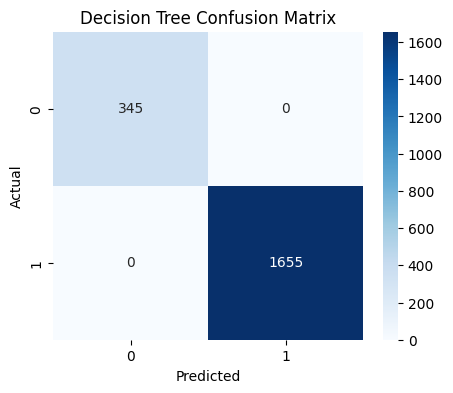

In [14]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [15]:
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))



Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



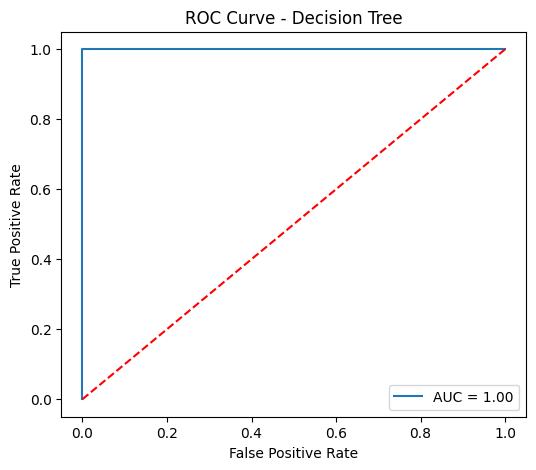

In [16]:
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob_dt)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr,
         label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)



Random Forest Accuracy:
1.0



Random Forest Confusion Matrix
[[ 345    0]
 [   0 1655]]


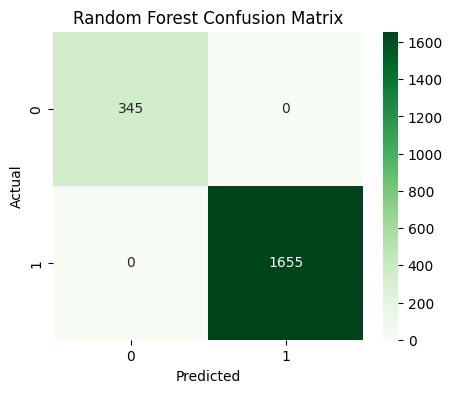

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nRandom Forest Confusion Matrix")
print(cm_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf))


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



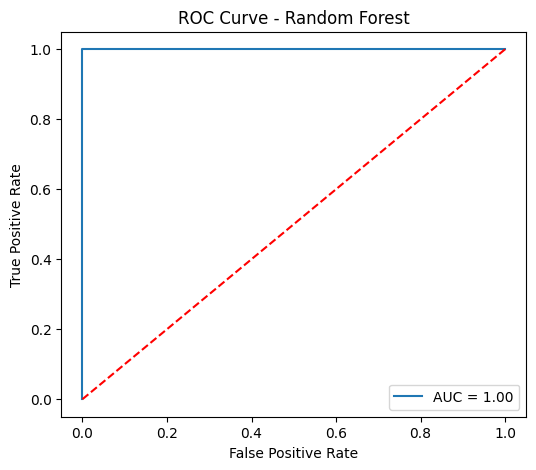

In [20]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, threshold_rf = roc_curve(y_test, y_prob_rf)

roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf,
         tpr_rf,
         label="AUC = %0.2f" % roc_auc_rf)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [23]:
print("\nModel Comparison")
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)


Model Comparison
Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0
